   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000
Intercept (b0): 180616.43835616432
Slope (b1): 135.78767123287673
Predicted price for 3300 sq ft: 628715.7534246575


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


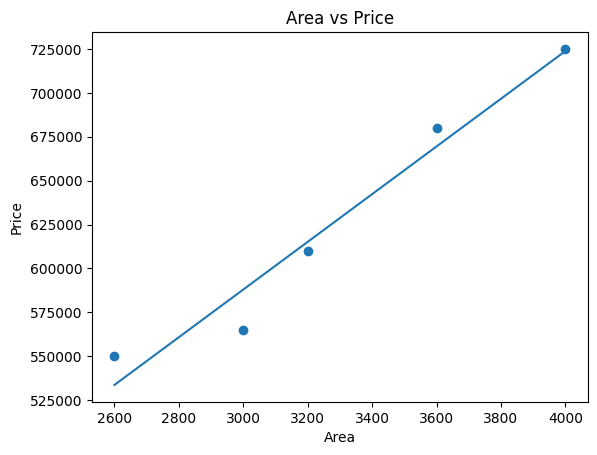

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('/content/housing_area_price.csv')

print(df.head())

# Define independent and dependent variables
X = df[['area']]
y = df['price']

# Create model
model = LinearRegression()
model.fit(X, y)

# Print coefficients
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

# Predict price for 3300 sq ft
pred = model.predict([[3300]])
print("Predicted price for 3300 sq ft:", pred[0])

# Plot
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/housing_area_price.csv')

print(df.head())

# Extract values
area = df['area'].values
price = df['price'].values

# Create design matrix (add column of 1s for intercept)
X = np.column_stack((np.ones(len(area)), area))
Y = price.reshape(-1, 1)

# Apply Normal Equation
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

b0 = beta[0][0]
b1 = beta[1][0]

print("Intercept (b0):", b0)
print("Slope (b1):", b1)

# Predict price for 3300 sq ft
pred = b0 + b1 * 3300
print("Predicted price for 3300 sq ft:", pred)



   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000
Intercept (b0): 180616.43835616513
Slope (b1): 135.787671232877
Predicted price for 3300 sq ft: 628715.7534246591


In [ ]:
# Import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('/content/homeprices_Multiple_LR.csv')

print(df)

# Fill missing values if any
df.bedrooms.fillna(df.bedrooms.median(), inplace=True)

# Define features and target
X = df[['area', 'bedrooms', 'age']]
y = df['price']

# Train model
model = LinearRegression()
model.fit(X, y)

# Print coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Predict example:
# area=3000, bedrooms=3, age=40
pred = model.predict([[3000, 3, 40]])
print("Predicted price:", pred[0])


   area  bedrooms  age   price
0  2600       3.0   20  550000
1  3000       4.0   15  565000
2  3200       NaN   18  610000
3  3600       3.0   30  595000
4  4000       5.0    8  760000
5  4100       6.0    8  810000
Intercept: 221323.00186540396
Coefficients: [  112.06244194 23388.88007794 -3231.71790863]
Predicted price: 498408.2515803067


/tmp/ipython-input-308674815.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.bedrooms.fillna(df.bedrooms.median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/homeprices_Multiple_LR.csv')

print(df)

# Fill missing bedroom values with median
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)

# Extract features and target
area = df['area'].values
bedrooms = df['bedrooms'].values
age = df['age'].values
price = df['price'].values

# Create design matrix (add column of 1s for intercept)
X = np.column_stack((np.ones(len(area)), area, bedrooms, age))
Y = price.reshape(-1, 1)

# Apply Normal Equation: β = (XᵀX)^(-1) XᵀY
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

# Print coefficients
print("Intercept:", beta[0][0])
print("Coefficient for Area:", beta[1][0])
print("Coefficient for Bedrooms:", beta[2][0])
print("Coefficient for Age:", beta[3][0])

# Prediction for area=3000, bedrooms=3, age=40
new_house = np.array([1, 3000, 3, 40])
prediction = new_house @ beta

print("Predicted price:", prediction[0])


   area  bedrooms  age   price
0  2600       3.0   20  550000
1  3000       4.0   15  565000
2  3200       NaN   18  610000
3  3600       3.0   30  595000
4  4000       5.0    8  760000
5  4100       6.0    8  810000
Intercept: 221323.00186546467
Coefficient for Area: 112.0624419421157
Coefficient for Bedrooms: 23388.880077944516
Coefficient for Age: -3231.7179086328506
Predicted price: 498408.25158033136


/tmp/ipython-input-3095363189.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('/content/canada_per_capita_income.csv')

# Display first few rows
print(df.head())

# Define X and y
X = df[['year']]
y = df['per capita income (US$)']

# Create model
model = LinearRegression()
model.fit(X, y)

# Predict for year 2020
pred_2020 = model.predict([[2020]])
print("Predicted Per Capita Income in 2020:", pred_2020[0])




   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
Predicted Per Capita Income in 2020: 41288.69409441762


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583
Intercept (b0): -1632210.7578560347
Slope (b1): 828.4650752229782
Predicted Per Capita Income in 2020: 41288.694094381295


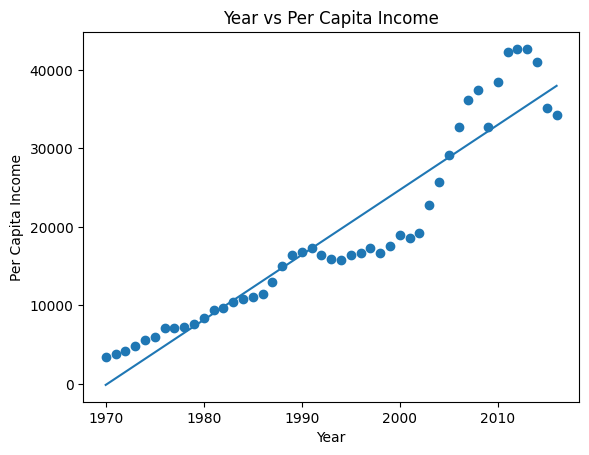

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/canada_per_capita_income.csv')

# Display first few rows
print(df.head())

# Extract values
year = df['year'].values
income = df['per capita income (US$)'].values

# Create design matrix (add column of 1s for intercept)
X = np.column_stack((np.ones(len(year)), year))
Y = income.reshape(-1, 1)

# Apply Normal Equation: β = (XᵀX)^(-1) XᵀY
beta = np.linalg.inv(X.T @ X) @ X.T @ Y

b0 = beta[0][0]
b1 = beta[1][0]

print("Intercept (b0):", b0)
print("Slope (b1):", b1)

# Predict for year 2020
pred_2020 = b0 + b1 * 2020
print("Predicted Per Capita Income in 2020:", pred_2020)

# Plot regression line
plt.scatter(year, income)
plt.plot(year, b0 + b1 * year)
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Year vs Per Capita Income")
plt.show()


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('/content/salary.csv')

print(df.head())

# Define X and y
X = df[['YearsExperience']]
y = df['Salary']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict salary for 12 years experience
pred_salary = model.predict([[12]])
print("Predicted Salary for 12 years experience:", pred_salary[0])


   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('/content/hiring.csv')

print(df)

# Data preprocessing
df['experience'].fillna(0, inplace=True)
df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].mean(), inplace=True)

# Define features and target
X = df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df['salary($)']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predictions
pred1 = model.predict([[2, 9, 6]])
pred2 = model.predict([[12, 10, 10]])

print("Salary for (2yr,9,6):", pred1[0])
print("Salary for (12yr,10,10):", pred2[0])


  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000
5      three                    7.0                          10      62000
6        ten                    NaN                           7      72000
7     eleven                    7.0                           8      80000


/tmp/ipython-input-147991508.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['experience'].fillna(0, inplace=True)
/tmp/ipython-input-147991508.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

ValueError: could not convert string to float: 'five'